# NjengaData — 03 Dashboard
**Four charts. Four findings. Built for non-technical judges.**

Each chart proves one answer to James's question.
All data is verified and citable.

| Chart | James asks | We prove |
|---|---|---|
| 1 | Where does my money go? | Land + infrastructure eat 34% before construction begins |
| 2 | Are costs rising? | Steel +77% since 2019. Every year of delay is expensive |
| 3 | Is it cheaper elsewhere? | Coast 5–8% more expensive. No cheap escape |
| 4 | Can I afford to build now? | Nairobi needs 6.8 years of household income |


## 0. Setup — one theme, one palette, one path

In [ ]:
import os, sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Working directory ──
repo_root = Path.home() / 'Documents' / 'njenga-data'
os.chdir(repo_root)

# ── Database ──
conn = sqlite3.connect("njenga.db")
def query(sql):
    return pd.read_sql(sql, conn)

# ── Universal theme ──
sns.set_theme(
    style="ticks",
    font="sans-serif",
    rc={
        "axes.spines.top":   False,
        "axes.spines.right": False,
        "figure.dpi":        150,
        "font.size":         11,
    }
)

# ── Colour palette ──
C = {
    "construction":   "#D85A30",
    "finance":        "#C0392B",
    "professional":   "#8E44AD",
    "preconstruction":"#2E86C1",
    "overheads":      "#95A5A6",
    "nairobi":        "#2E86C1",
    "coast":          "#D85A30",
    "western":        "#27AE60",
    "cement":         "#2E86C1",
    "steel":          "#D85A30",
    "hardcore":       "#27AE60",
    "highlight":      "#D85A30",
    "neutral":        "#2E86C1",
}

# ── Output folder ──
CHARTS = Path("data/processed/charts")
CHARTS.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print(f"Charts will save to: {CHARTS.resolve()}")


Setup complete.
Charts will save to: /home/miringu/Documents/njenga-data/data/processed/charts


## Chart 1 — Where does James's money go?
**Proves:** Land and infrastructure consume over 34% of a standalone build before construction begins.  
**Data:** CAHF Housing Development Cost Benchmark Kenya 2022  
**Chart:** Horizontal stacked bar — 5 grouped cost buckets, KES axis, legend below


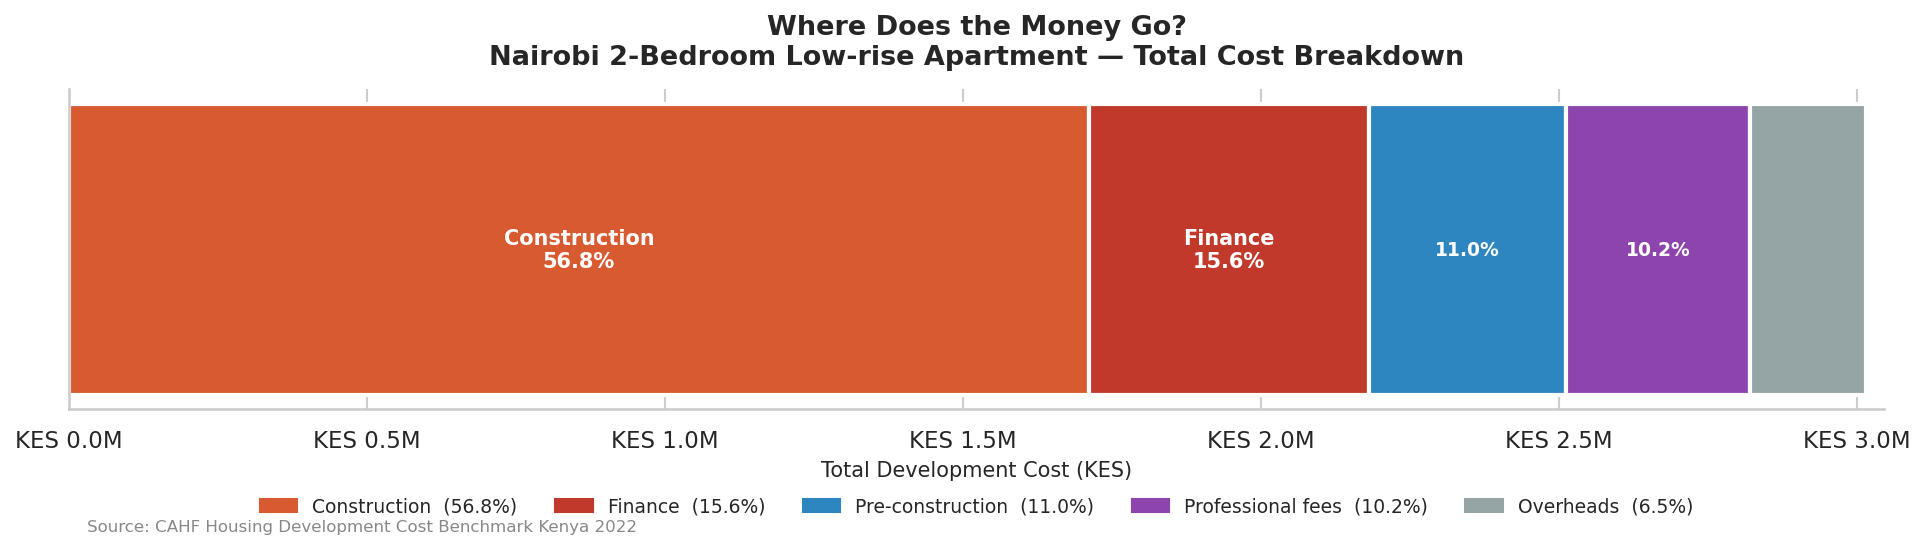

Saved: chart_1_cost_breakdown.png


In [48]:
# Load and group
df1 = query('''
    SELECT cost_category, amount_kes, pct_of_total
    FROM cahf_cost_breakdown
    WHERE unit_type = '2BR_lowrise'
    ORDER BY pct_of_total DESC
''')

GROUP_MAP = {
    "Construction":            "Construction",
    "Finance":                 "Finance",
    "Professional fees":       "Professional fees",
    "Land":                    "Pre-construction",
    "Infrastructure":          "Pre-construction",
    "Compliance":              "Pre-construction",
    "Developer overhead":      "Overheads",
    "Marketing":               "Overheads",
    "Other development costs": "Overheads",
}
BUCKET_COLOURS = {
    "Construction":     C["construction"],
    "Finance":          C["finance"],
    "Professional fees":C["professional"],
    "Pre-construction": C["preconstruction"],
    "Overheads":        C["overheads"],
}

df1["bucket"] = df1["cost_category"].map(GROUP_MAP)
df1g = df1.groupby("bucket", as_index=False).agg(
    amount_kes   =("amount_kes",   "sum"),
    pct_of_total =("pct_of_total", "sum")
).sort_values("amount_kes", ascending=False)

# ── Build chart ──
fig, ax = plt.subplots(figsize=(13, 4))
left = 0
handles = []

for _, row in df1g.iterrows():
    colour = BUCKET_COLOURS[row["bucket"]]
    ax.barh(0, row["amount_kes"], left=left, height=0.5,
            color=colour, edgecolor="white", linewidth=2)
    pct = row["pct_of_total"]
    if pct >= 12:
        ax.text(left + row["amount_kes"] / 2, 0,
                f"{row['bucket']}\n{pct:.1f}%",
                ha="center", va="center",
                fontsize=10, color="white", fontweight="bold")
    elif pct >= 7:
        ax.text(left + row["amount_kes"] / 2, 0,
                f"{pct:.1f}%",
                ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")
    left += row["amount_kes"]
    handles.append(mpatches.Patch(
        color=colour, label=f"{row['bucket']}  ({pct:.1f}%)"))

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"KES {v/1e6:.1f}M"))
ax.set_xlim(0, df1g["amount_kes"].sum() * 1.01)
ax.set_yticks([])
ax.set_xlabel("Total Development Cost (KES)", fontsize=10)
ax.set_title(
    "Where Does the Money Go?\n"
    "Nairobi 2-Bedroom Low-rise Apartment — Total Cost Breakdown",
    fontsize=13, fontweight="bold", pad=12)
ax.legend(handles=handles, loc="upper center",
          bbox_to_anchor=(0.5, -0.22), ncol=5,
          frameon=False, fontsize=9)
ax.text(0.01, -0.38,
        "Source: CAHF Housing Development Cost Benchmark Kenya 2022",
        transform=ax.transAxes, fontsize=8, color="#888888")

plt.tight_layout()
fig.subplots_adjust(bottom=0.30)
plt.savefig(CHARTS / "chart_1_cost_breakdown.png",
            bbox_inches="tight", dpi=150)
plt.show()
print("Saved: chart_1_cost_breakdown.png")


## Chart 2 — Are costs rising?
**Proves:** Steel +77% since 2019. Every year of delay is expensive.  
**Data:** KNBS Construction Input Price Index 2021–2025  
**Chart:** Line chart — annual averages, three materials, supply chain spike annotated


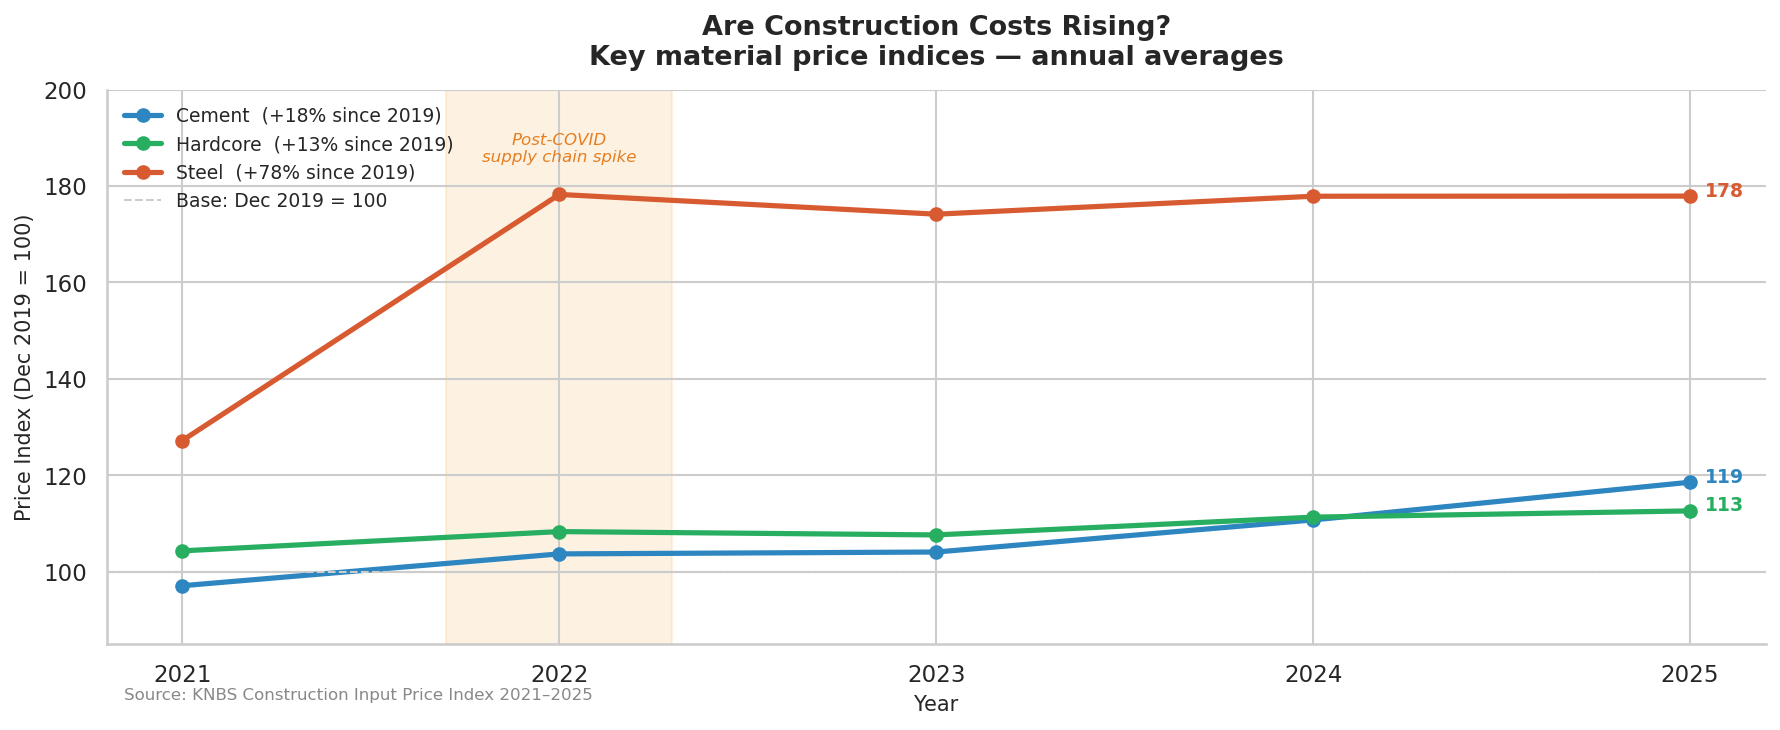

Saved: chart_2_price_trends.png


In [49]:
df2 = query('''
    SELECT product, year, quarter, index_value
    FROM knbs_material_index
    WHERE product IN ('Cement', 'Steel and reinforced bars', 'Hardcore')
    ORDER BY product, year, quarter
''')

# Annual averages — smoother for presentation
df2a = df2.groupby(["product","year"])["index_value"].mean().reset_index()
df2a.columns = ["product","year","avg_index"]

# % change from base 100 (Dec 2019) to latest
pct = {}
for p, g in df2a.groupby("product"):
    pct[p] = round(g.sort_values("year")["avg_index"].iloc[-1] - 100, 1)

LINE = {
    "Cement":                    C["cement"],
    "Steel and reinforced bars": C["steel"],
    "Hardcore":                  C["hardcore"],
}
NAMES = {
    "Cement":                    "Cement",
    "Steel and reinforced bars": "Steel",
    "Hardcore":                  "Hardcore",
}

fig, ax = plt.subplots(figsize=(12, 5))

# Supply chain spike annotation
ax.axvspan(2021.7, 2022.3, color="#F39C12", alpha=0.12, zorder=0)
ax.text(2022, 185, "Post-COVID\nsupply chain spike",
        ha="center", fontsize=8, color="#E67E22", style="italic")

for product, group in df2a.groupby("product"):
    group  = group.sort_values("year")
    colour = LINE[product]
    name   = NAMES[product]
    ax.plot(group["year"], group["avg_index"],
            marker="o", markersize=6,
            linewidth=2.5, color=colour,
            label=f"{name}  (+{pct[product]:.0f}% since 2019)")
    ax.annotate(
        f"{group['avg_index'].iloc[-1]:.0f}",
        xy=(group["year"].iloc[-1], group["avg_index"].iloc[-1]),
        xytext=(7, 0), textcoords="offset points",
        fontsize=9, color=colour, fontweight="bold")

ax.axhline(100, color="#CCCCCC", linewidth=1, linestyle="--",
           label="Base: Dec 2019 = 100")
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Price Index (Dec 2019 = 100)", fontsize=10)
ax.set_xticks(sorted(df2a["year"].unique()))
ax.set_ylim(85, 200)
ax.set_title(
    "Are Construction Costs Rising?\n"
    "Key material price indices — annual averages",
    fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="upper left", frameon=False, fontsize=9)
ax.text(0.01, -0.10,
        "Source: KNBS Construction Input Price Index 2021–2025",
        transform=ax.transAxes, fontsize=8, color="#888888")

plt.tight_layout()
plt.savefig(CHARTS / "chart_2_price_trends.png",
            bbox_inches="tight", dpi=150)
plt.show()
print("Saved: chart_2_price_trends.png")


## Chart 3 — Is it cheaper to build elsewhere?
**Proves:** Coast is 5–8% more expensive than Nairobi. No cheap escape.  
**Data:** Integrum Regional Construction Cost Reports 2021–2024  
**Chart:** Grouped bar — regions on x-axis, years as bar groups


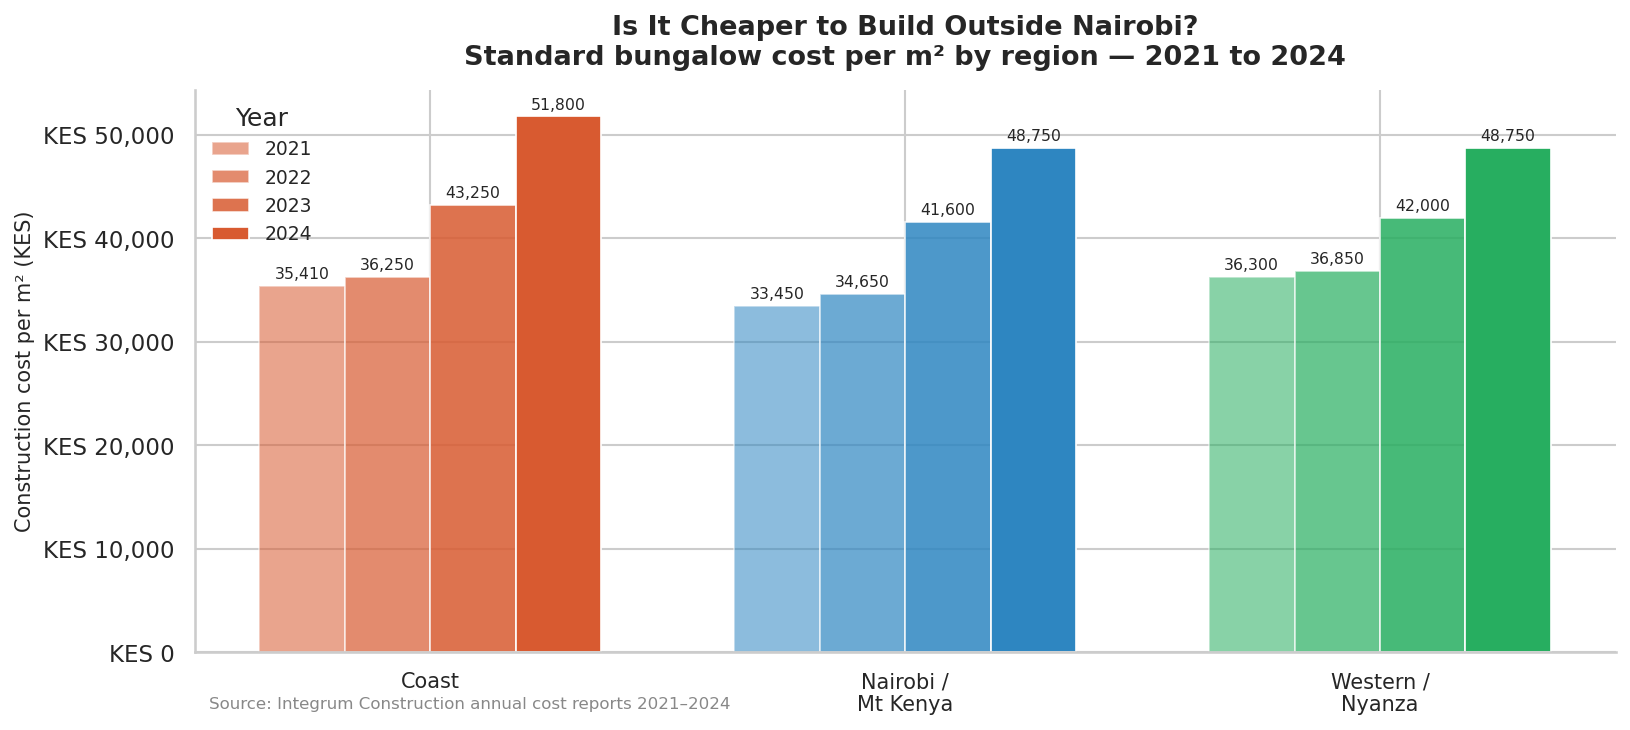

Saved: chart_3_regional_costs.png


In [50]:
df3 = query('''
    SELECT year, region, cost_per_m2
    FROM integrum_regional_costs
    WHERE cost_per_m2 IS NOT NULL AND year <= 2024
    ORDER BY region, year
''')

REGION_COLOURS = {
    "Nairobi/Mt Kenya": C["nairobi"],
    "Coast":            C["coast"],
    "Western/Nyanza":   C["western"],
}
REGION_SHORT = {
    "Nairobi/Mt Kenya": "Nairobi /\nMt Kenya",
    "Coast":            "Coast",
    "Western/Nyanza":   "Western /\nNyanza",
}

regions = df3["region"].unique()
years   = sorted(df3["year"].unique())
n_years = len(years)
width   = 0.18
x       = range(len(regions))

fig, ax = plt.subplots(figsize=(11, 5))

for j, year in enumerate(years):
    offsets = [xi + (j - n_years/2 + 0.5) * width for xi in x]
    vals = []
    for region in regions:
        row = df3[(df3["region"]==region) & (df3["year"]==year)]
        vals.append(row["cost_per_m2"].values[0] if len(row) else 0)

    # Lighten colour by year — oldest darkest, latest brightest
    alpha = 0.55 + (j / (n_years - 1)) * 0.45
    bar_colours = [REGION_COLOURS[r] for r in regions]

    bars = ax.bar(offsets, vals, width=width,
                  color=bar_colours, alpha=alpha,
                  edgecolor="white", linewidth=0.8,
                  label=str(year))
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 400,
                    f"{int(val):,}",
                    ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(list(x))
ax.set_xticklabels(
    [REGION_SHORT[r] for r in regions],
    fontsize=10)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"KES {int(v):,}"))
ax.set_ylabel("Construction cost per m² (KES)", fontsize=10)
ax.set_title(
    "Is It Cheaper to Build Outside Nairobi?\n"
    "Standard bungalow cost per m² by region — 2021 to 2024",
    fontsize=13, fontweight="bold", pad=12)
ax.legend(title="Year", loc="upper left",
          frameon=False, fontsize=9)
ax.text(0.01, -0.10,
        "Source: Integrum Construction annual cost reports 2021–2024",
        transform=ax.transAxes, fontsize=8, color="#888888")

plt.tight_layout()
plt.savefig(CHARTS / "chart_3_regional_costs.png",
            bbox_inches="tight", dpi=150)
plt.show()
print("Saved: chart_3_regional_costs.png")


## Chart 4 — Can James afford to build now?
**Proves:** A Nairobi household needs 6.8 years of total income to build a 2BR apartment.  
**Data:** CAHF (build cost) + KCHS 2022 (household income)  
**Chart:** Horizontal bar — years to build by county, Nairobi highlighted


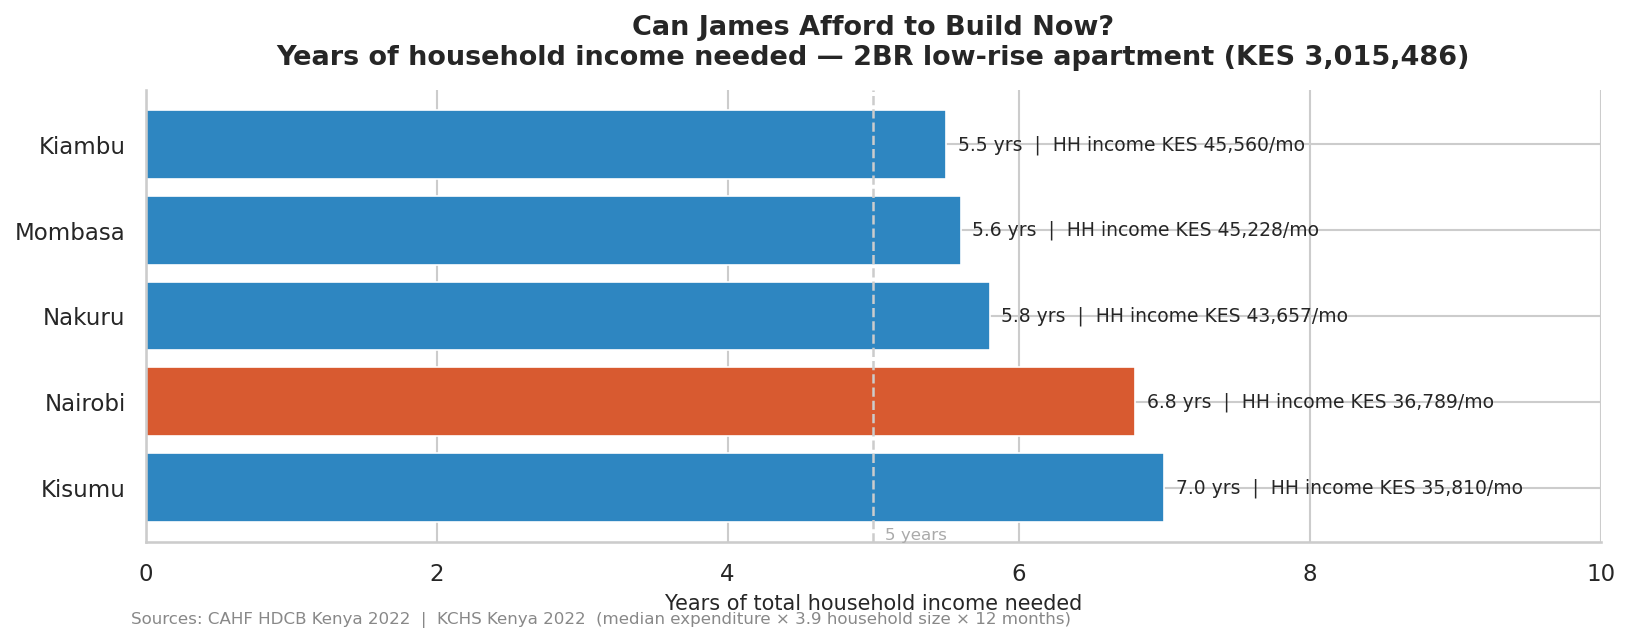

Saved: chart_4_affordability.png


In [51]:
df4 = query('''
    SELECT county, hh_monthly_kes,
           ROUND(3015486.0 / hh_annual_kes, 1) AS years_to_build
    FROM county_income_urban
    WHERE county IN ('Nairobi','Mombasa','Nakuru','Kiambu','Kisumu')
    AND is_national = 0
    ORDER BY years_to_build DESC
''')

bar_colours = [
    C["highlight"] if c == "Nairobi" else C["neutral"]
    for c in df4["county"]
]

fig, ax = plt.subplots(figsize=(11, 4.5))

bars = ax.barh(df4["county"], df4["years_to_build"],
               color=bar_colours, edgecolor="white", linewidth=0.8)

for bar, (_, row) in zip(bars, df4.iterrows()):
    ax.text(
        bar.get_width() + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{row['years_to_build']} yrs  |  HH income KES {int(row['hh_monthly_kes']):,}/mo",
        va="center", fontsize=9)

ax.set_xlabel("Years of total household income needed", fontsize=10)
ax.set_xlim(0, df4["years_to_build"].max() + 3)
ax.axvline(5, color="#CCCCCC", linewidth=1.2, linestyle="--")
ax.text(5.08, -0.6, "5 years", fontsize=8, color="#AAAAAA")
ax.set_title(
    "Can James Afford to Build Now?\n"
    "Years of household income needed — 2BR low-rise apartment (KES 3,015,486)",
    fontsize=13, fontweight="bold", pad=12)
ax.text(-0.01, -0.18,
        "Sources: CAHF HDCB Kenya 2022  |  KCHS Kenya 2022  "
        "(median expenditure × 3.9 household size × 12 months)",
        transform=ax.transAxes, fontsize=8, color="#888888", ha="left")

plt.tight_layout()
plt.savefig(CHARTS / "chart_4_affordability.png",
            bbox_inches="tight", dpi=150)
plt.show()
print("Saved: chart_4_affordability.png")


## All Charts Complete

In [ ]:
charts = sorted(CHARTS.glob("*.png"))
print(f"Charts saved ({len(charts)}):")
for c in charts:
    print(f"  {c.name:45}  {c.stat().st_size // 1024} KB")

conn.close()
print("\nDashboard complete. Ready for presentation.")
